# Application 1 : Équation de diffusion-réaction généralisée

On considère l’équation de diffusion-réaction stationnaire, où $\mu$, $\gamma$ sont des constantes positives : 

$$
\begin{cases}
-\mu u''(x) + \gamma u(x) = 0 & \text{dans } ]0, 1[ \\
u(0) = 0, \text{ } u(1) = 1
\end{cases} \quad  \text{ } (5)
$$

où : 

- $\mu > 0$ est le coefficient de diffusion,  
- $\gamma > 0$ est le coefficient de réaction.  

## Questions

1. Donner la solution analytique de (5).  

2. Écrire un programme simulant la solution de (5) et la comparer à la solution exacte, pour le même pas d’espace $h$ et pour un choix de $\mu$ et $\gamma$, tel que :  
   - a) $\frac{\gamma}{6\mu} \ll 1$  
   - b) $\frac{\gamma}{6\mu} \gg 1$  

   Ce nombre est le **Péclet**, qui mesure le rapport entre les phénomènes diffusifs et réactifs.  
   - S’il est $\gg 1$, c’est la réaction qui domine sur la diffusion.  
   - S’il est $\ll 1$, c’est la diffusion qui domine.  

3. Pour $\frac{\gamma}{6\mu} \gg 1$ (par exemple de l’ordre de 1000), varier le pas d’espace $h$ en prenant :  
   - $h^2 \frac{\gamma}{6\mu} \leq 1$  
   - $h^2 \frac{\gamma}{6\mu} \geq 1$.  

   Ce nombre est le **Péclet local**.  

4. Quel critère de stabilité pouvez-vous en déduire ?


In [2]:
# =============================================
# Résolution de l'Équation de Diffusion-Réaction Généralisée
# -μd²u/dx² + γc(x)u = f avec x dans ]0 ,1[, avec
# −μu′′(x)+γu(x)=0,avec u(0)=0 et u(1)=1.
# f(x)=0 et c(x)= γ
# et les conditions aux limites u(0) = 0, u(1) = 1
# ==============================================

## 1. Solution analytique de l'équation

L'équation donnée est :

$$
-\mu u''(x) + \gamma u(x) = 0, \quad u(0) = 0 \quad \text{et} \quad u(1) = 1.
$$

**Forme générale de la solution**

L'équation est une EDO linéaire à coefficients constants. 

$$
-\mu \frac{d^2 u(x)}{dx^2} + \gamma \frac{du(x)}{dx} = 0
$$

ou encore

$$
\mu u''(x)  = \gamma u(x)
$$

et donc 

$$
u''(x)  = \frac{\gamma}{\mu} u(x)
$$

Posons 

$$
\lambda = \frac{\gamma}{\mu},
$$ 

ce qui donne :

$$
u''(x) - \lambda u(x) = 0
$$

Cette équation est une équation différentielle linéaire homogène du second ordre à coefficients constants.



Les équations différentielles linéaires à coefficients constants, comme :

$$
u''(x) - \lambda u(x) = 0,
$$

ont des solutions fondamentales de la forme $e^{rx}$, car elles impliquent des relations polynomiales sur les coefficients de $u(x)$, $u'(x)$, et $u''(x)$.

**Équation caractéristique :**

On suppose une solution de la forme $u(x) = e^{rx}$.  
En substituant $u(x) = e^{rx}$ dans l'équation, on obtient :

$$
r^2 e^{rx} - \lambda e^{rx} = 0.
$$

Simplifions par $e^{rx} \neq 0$ :

$$
r^2 - \lambda r = 0.
$$

L'équation caractéristique est donc :

$$
r^2 - \lambda r = 0.
$$

**Résolution de l'équation caractéristique :**

L'équation $r^2 - \lambda r = 0$ est une équation quadratique qui se factorise :

$$
(r)(r - \lambda) = 0.
$$

Les racines de cette équation sont :

$$
r_1 = \lambda \quad \text{et} \quad r_2 = 0.
$$

**Solution générale :**

La solution générale de l'équation est une combinaison linéaire des solutions fondamentales $e^{r_1 x}$ et $e^{r_2 x}$ :

$$
u(x) = C_1 e^{\lambda x} + C_2,
$$

où $C_1$ et $C_2$ sont des constantes d'intégration.

**La solution générale de cette EDO est :**

$$
u(x) = C_1 e^{\lambda x} + C_2.
$$

**Conditions aux limites**

- $u(0) = 0$ implique $C_1 + C_2 = 0$, donc $C_2 = -C_1$.
- $u(1) = 1$ implique :  

$$
C_1 \left( e^{\lambda} - e^{-\lambda} \right) = 1.
$$

En isolant $C_1$ :  

$$
C_1 = \frac{1}{e^{\lambda} - e^{-\lambda}}.
$$

En remplaçant $C_1$ et $C_2$ dans l'expression de $u(x)$ :  

$$
u(x) = C_1 e^{\lambda x} + (-C_1) e^{-\lambda x}.
$$

Ce qui devient :  

$$
u(x) = C_1 \left( e^{\lambda x} - e^{-\lambda x} \right).
$$

En remplaçant $C_1$ par son expression :  

$$
u(x) = \frac{1}{e^{\lambda} - e^{-\lambda}} \left( e^{\lambda x} - e^{-\lambda x} \right).
$$

En simplifiant :  

$$
u(x) = \frac{e^{\lambda x} - e^{-\lambda x}}{e^{\lambda} - e^{-\lambda}}.
$$

En remplaçant $ \lambda = \frac{\gamma}{\mu} $ :  

$$
u(x) = \frac{e^{\frac{\gamma x}{\mu}} - e^{-\frac{\gamma x}{\mu}}}{e^{\frac{\gamma}{\mu}} - e^{-\frac{\gamma}{\mu}}}.
$$

**La solution finale devient donc :**  

$$
u(x) = \frac{e^{\frac{\gamma x}{\mu}}}{e^{\frac{\gamma}{\mu}} - 1} - \frac{1}{e^{\frac{\gamma}{\mu}} - 1}.
$$


In [3]:
from sympy import symbols, Function, Eq, dsolve, exp

# Define variables and function
x = symbols('x')
y = Function('y')
mu, gamma = symbols('mu gamma')

# Define the equation
edp = Eq(-mu * y(x).diff(x, 2) + gamma * y(x).diff(x), 0)

# Solve the equation with boundary conditions
solution_analytique = dsolve(edp, ics={y(0): 0, y(1): 1})

# Display the solution
print("Solution particulière de l'EDO avec condition initiale:\n", solution_analytique)


Solution particulière de l'EDO avec condition initiale:
 Eq(y(x), exp(gamma*x/mu)/(exp(gamma/mu) - 1) - 1/(exp(gamma/mu) - 1))


In [4]:
solution_analytique

Eq(y(x), exp(gamma*x/mu)/(exp(gamma/mu) - 1) - 1/(exp(gamma/mu) - 1))

## 2. Écrire un programme simulant la solution de (5) et la comparer à la solution exacte, pour le même pas d’espace $h$ et pour un choix de $\mu$ et $\gamma$, tel que :  
   - a) $\frac{\gamma}{6\mu} \ll 1$  
   - b) $\frac{\gamma}{6\mu} \gg 1$  

   Ce nombre est le **Péclet**, qui mesure le rapport entre les phénomènes diffusifs et réactifs.  
   - S’il est $\gg 1$, c’est la réaction qui domine sur la diffusion.  
   - S’il est $\ll 1$, c’est la diffusion qui domine. 


---

### Résolution numérique de l'équation différentielle 

**1. Rappel de l'équation et discrétisation**

L'équation différentielle est :
$$
-\mu u''(x) + \gamma u(x) = 0,
$$
avec :
- $\mu > 0$ : le coefficient de la dérivée seconde,
- $\gamma > 0$ : le coefficient de $u(x)$,
- Les conditions aux limites : $u(0) = 0$ et $u(1) = 1$.

---

**2. Discrétisation du domaine**

Pour résoudre numériquement cette équation, nous divisons le domaine $[0,1]$ en $N$ points avec un pas $h = \frac{1}{N}$. Les points de discrétisation sont donnés par :
$$
x_i = i \cdot h, \quad \text{où } i = 0, 1, \dots, N.
$$

---

**3. Approximation par différences finies**

**3.1. Approximations des dérivées**

Nous utilisons les différences finies pour approximer les dérivées.

**Dérivée seconde ($u''(x)$) :**

$$
u''(x_i) \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}.
$$

En substituant cette approximation dans l'équation, nous avons :
$$
-\mu \cdot \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} + \gamma u_i = 0.
$$

**3.2. Réorganisation de l'équation discrète**

Réorganisons l'équation pour $i = 1, 2, \dots, N-1$ :
$$
-\frac{\mu}{h^2} u_{i-1} + \left( \frac{2\mu}{h^2} + \gamma \right) u_i - \frac{\mu}{h^2} u_{i+1} = 0.
$$

On factorise par $\frac{\mu}{h^2}$ :

$$
\frac{\mu}{h^2} \left( -u_{i-1} + \left( 2 + \frac{\gamma h^2}{\mu} \right) u_i - u_{i+1} \right) = 0.
$$

ou:

$$
\frac{\mu}{h^2} \left( -u_{i-1} + 2u_i + \left( \frac{\gamma h^2}{\mu} \right) u_i - u_{i+1} \right) = 0.
$$

ou encore:

$$
\frac{\mu}{h^2} \left( -u_{i-1} + 2u_i - u_{i+1} \right) + \gamma u_i = 0.
$$

Cette équation discrète relie $u_{i-1}$, $u_i$, et $u_{i+1}$. Nous devons résoudre ce système pour les $u_i$ à l'intérieur du domaine.

---

Le problème s'écrit : 

$$
A \mathbf{U} = \mathbf{F}
$$

avec :

Matrice $A$ :

$$
A = \left( \frac{\mu}{h^2} \left(
\begin{matrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
0 & -1 & 2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & \cdots & 0 & -1 & 2
\end{matrix}
\right)
+ 
\left(
\begin{matrix}
\gamma & 0 & 0 & \cdots & 0 \\
0 & \gamma & 0 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & \cdots & 0 & \gamma & 0 \\
0 & \cdots & 0 & 0 & \gamma
\end{matrix}
\right)
\right)
$$

Vecteur $\mathbf{U}$ :

$$
\mathbf{U} = 
\begin{pmatrix}
u_1 \\
u_2 \\
\vdots \\
u_{N-1}
\end{pmatrix}
$$

Vecteur $\mathbf{F}$ :

$$
\mathbf{F} = 
\begin{pmatrix}
0 \\
0 \\
\vdots \\
1
\end{pmatrix}
$$


---

**4. Formulation matricielle**

Le système discrétisé peut être écrit sous forme matricielle :
$$
\mathbf{A} \mathbf{U} = \mathbf{F},
$$
où :
- $\mathbf{A}$ est une matrice tridiagonale $(N-1) \times (N-1)$,
- $\mathbf{U} = [u_1, u_2, \dots, u_{N-1}]$ est le vecteur des inconnues,
- $\mathbf{F} = [0, 0, \dots, 0, u_N]$ est le vecteur des termes constants, tenant compte des conditions aux limites.

---

**4.1. Construction de la matrice $\mathbf{A}$**

La matrice tridiagonale $\mathbf{A}$ est définie par les coefficients suivants :
$$
\mathbf{A}_{ii} = \frac{2\mu}{h^2} + \gamma, \quad \mathbf{A}_{i,i-1} = \mathbf{A}_{i,i+1} = -\frac{\mu}{h^2}.
$$

---

**4.2. Termes constants $\mathbf{F}$**

Le vecteur $\mathbf{F}$ est nul partout sauf au dernier élément, où il prend en compte la condition $u(1) = 1$ :
$$
\mathbf{F} = [0, 0, \dots, 0, 1].
$$

---


In [5]:
# IMPORTATION DES LIBRAIRIES
# ==========================
import numpy as np
from sympy import symbols, Function, Eq, dsolve, exp
from sympy.abc import x, C
from scipy.sparse import dia_matrix
import sympy as sp
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm

In [6]:
# MAILLAGE DU DOMAINE
# =============================
# Discrétisation du domaine spatial avec un pas dx.

def maillage_domaine(NX): 
    """
    Génère le maillage du domaine spatial.
    """
    x = np.linspace(0, 1, NX)  # Positions discrètes sur le domaine [0,1]
    dx = 1 / (NX - 1)  # Pas de discrétisation
    return x, dx


In [7]:
NX = 10
x, dx = maillage_domaine(NX)
mu = 1
gamma = 10

In [8]:
# DÉFINITION DES FONCTIONS
# =========================
def func_f(x):
    return 0  # Fonction source f(x)

def func_c(gamma):
    return gamma  # Coefficient c(x)

def solution_exacte(x):
    return (exp(gamma*x/mu)/(exp(gamma/mu) - 1) - 1/(exp(gamma/mu) - 1))

f = np.vectorize(func_f)
c = np.vectorize(func_c)

In [9]:
# CALCUL DE LA SOLUTION DISCRETE
# ================================
def U_discret(x, NX, dx, f, c):
    U = np.zeros((NX,))  # Initialisation du vecteur solution
    U[0] = 0  # Condition limite u(0) = 0
    U[-1] = 1  # Condition limite u(1) = 0
    F = f(x)
    C = c(x)
    F = F[1:NX-1] 
    C = C[1:NX-1]

    val_diags = [-np.ones(NX - 2), 2 * np.ones(NX - 2), -np.ones(NX - 2)]  # Coefficients diagonaux
    positions = np.array([-1, 0, 1])  # Positions des diagonales
    A1 = dia_matrix((val_diags, positions), shape=(NX - 2, NX - 2))  # Matrice de Laplacien
    A2 = C * np.eye(NX-2, NX-2)
    A = (mu/dx**2) * A1 + A2
    Uint = spsolve(A, F)  # Resolution du systeme lineaire
    U[1 : NX - 1] = Uint  # Insertion des valeurs interieures

    return U

In [10]:
Uex = np.vectorize ( solution_exacte )
Uexact = Uex ( x )

c:\Users\bmd tech\anaconda3\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


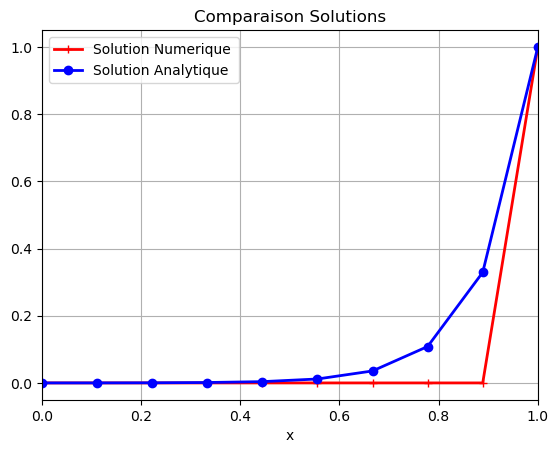

In [11]:
# AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
# =========================================================
U = U_discret(x, NX, dx, f, c)  # Solution numerique

fig, ax = plt.subplots(1)
ax.plot(x, U, "r-+", lw=2, label="Solution Numerique")  # Courbe solution numerique
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel("x")
# ax.set_ylabel("y")
ax.set_xlim([0, 1])
# ax.set_ylim([0, 0.11])
ax.set_title("Comparaison Solutions")
ax.legend()
ax.grid()
plt.show()

In [12]:
def simulation(NX, f, c, mu, gamma):
    x, dx = maillage_domaine(NX)
    f = np.vectorize(func_f)
    c = np.vectorize(func_c)
    Uex = np.vectorize ( solution_exacte )
    Uexact = Uex ( x )
    U = U_discret(x, NX, dx, f, c)

    fig, ax = plt.subplots(1)
    ax.plot(x, U, "r-+", lw=2, label="Solution Numerique")  # Courbe solution numerique
    ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
    ax.set_xlabel("x")
    # ax.set_ylabel("y")
    ax.set_xlim([0, 1])
    # ax.set_ylim([0, 0.11])
    ax.set_title("Comparaison Solutions")
    ax.legend()
    ax.grid()
    plt.show()



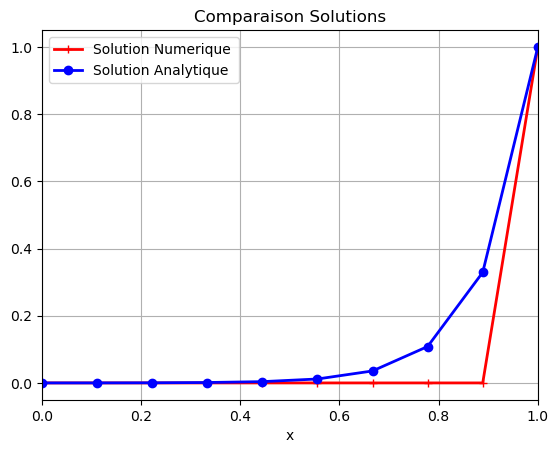

In [13]:
simulation(10,f,c,1,0.01)

a) $\frac{\gamma}{6\mu} \ll 1$  

In [14]:
gamma = g = 0.01
mu = u = 1
print(gamma / (6 * mu))

0.0016666666666666668


In [15]:
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace h
g = 0.01
u = 1
alpha = 0
beta = 1

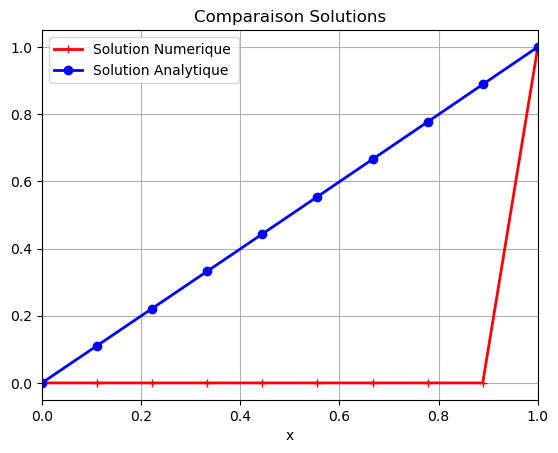

In [16]:
simulation(10,f,c,1,0.01)

b) $\frac{\gamma}{6\mu} \gg 1$ 

In [17]:
gamma = g = 1
mu = u = 0.01
print(gamma / (6 * mu))

16.666666666666668


In [18]:
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.01
alpha = 0
beta = 1

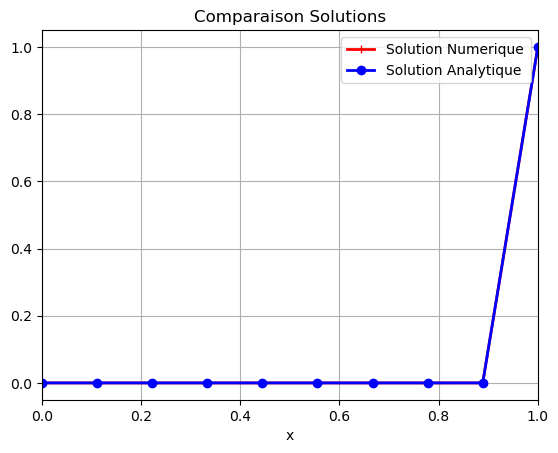

In [19]:
simulation(10,f,c,0.01,1)

In [20]:
# # Importation des bibliothèques nécessaires
# import numpy as np
# from scipy.sparse import dia_matrix
# from scipy.sparse.linalg import spsolve
# import matplotlib.pyplot as plt

# # Définition des paramètres
# mu = 1  # Coefficient de diffusion
# gamma = [0.01, 1000]  # Coefficient de réaction pour les deux cas
# NX = 50  # Nombre de points sur le maillage

# # Fonction pour générer le maillage du domaine
# def maillage_domaine(NX): 
#     x = np.linspace(0, 1, NX)  # Positions discrètes sur le domaine [0,1]
#     dx = 1 / (NX - 1)  # Pas de discrétisation
#     return x, dx

# # Solution analytique
# def solution_exacte(x, mu, gamma):
#     return (np.exp(gamma * x / mu) - 1) / (np.exp(gamma / mu) - 1)

# # Résolution numérique de l'équation différentielle
# def U_discret(x, NX, dx, mu, gamma):
#     U = np.zeros(NX)  # Initialisation du vecteur solution
#     U[0] = 0  # Condition limite u(0) = 0
#     U[-1] = 1  # Condition limite u(1) = 1

#     # Construction de la matrice et du vecteur source
#     val_diags = [-np.ones(NX - 2), 2 * np.ones(NX - 2), -np.ones(NX - 2)]
#     positions = [-1, 0, 1]
#     A = dia_matrix((val_diags, positions), shape=(NX - 2, NX - 2)) * (mu / dx**2)
#     A += gamma * np.eye(NX - 2)

#     F = np.zeros(NX - 2)  # Pas de terme source (f(x) = 0)

#     # Résolution du système linéaire
#     U[1:-1] = spsolve(A, F)
#     return U

# # Simulation et comparaison
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# for i, g in enumerate(gamma):
#     x, dx = maillage_domaine(NX)
#     U_analytique = solution_exacte(x, mu, g)
#     U_numerique = U_discret(x, NX, dx, mu, g)
    
#     # Affichage des résultats
#     ax = axes[i]
#     ax.plot(x, U_analytique, label="Solution analytique", linestyle="--", color="blue")
#     ax.plot(x, U_numerique, label="Solution numérique", marker="o", color="red")
#     ax.set_xlabel("x")
#     ax.set_ylabel("u(x)")
#     ax.set_title(f"Comparaison des solutions (gamma={g})")
#     ax.legend()
#     ax.grid()

# plt.tight_layout()
# plt.show()


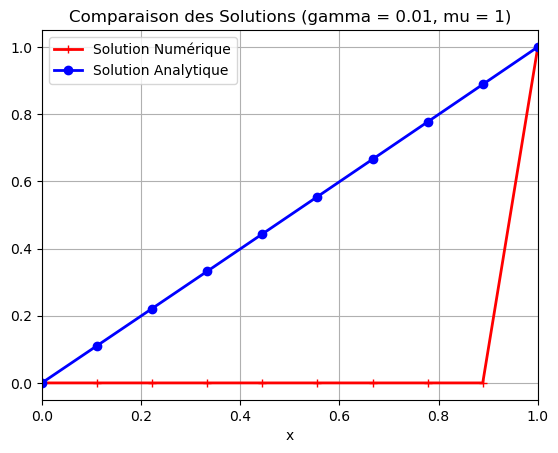

C:\Users\bmd tech\AppData\Local\Temp\ipykernel_5796\298534084.py:38: RuntimeWarning: overflow encountered in exp
  return (np.exp(gamma * x / mu) / (np.exp(gamma / mu) - 1) - 1 / (np.exp(gamma / mu) - 1))
C:\Users\bmd tech\AppData\Local\Temp\ipykernel_5796\298534084.py:38: RuntimeWarning: invalid value encountered in divide
  return (np.exp(gamma * x / mu) / (np.exp(gamma / mu) - 1) - 1 / (np.exp(gamma / mu) - 1))


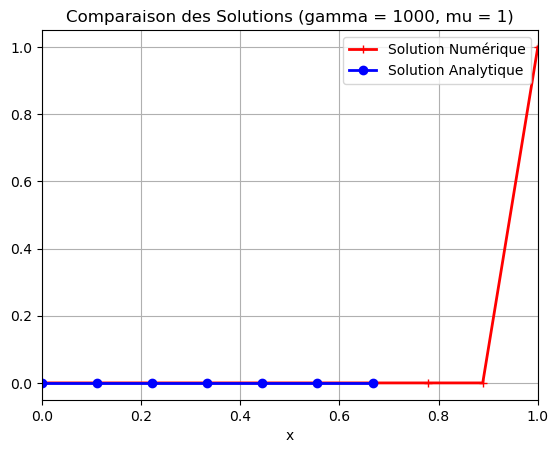

In [21]:
# IMPORTATION DES LIBRAIRIES
# ==========================
import numpy as np
from sympy import exp
from scipy.sparse import dia_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

# MAILLAGE DU DOMAINE
# =============================
# Discrétisation du domaine spatial avec un pas dx.
def maillage_domaine(NX):
    """
    Génère le maillage du domaine spatial.
    """
    x = np.linspace(0, 1, NX)  # Positions discrètes sur le domaine [0,1]
    dx = 1 / (NX - 1)  # Pas de discrétisation
    return x, dx

# DÉFINITION DES FONCTIONS
# =========================
def func_f(x):
    """
    Fonction source f(x). Ici, elle est nulle.
    """
    return 0

def func_c(gamma):
    """
    Coefficient c(x) constant.
    """
    return gamma

def solution_exacte(x, gamma, mu):
    """
    Solution analytique exacte du problème.
    """
    return (np.exp(gamma * x / mu) / (np.exp(gamma / mu) - 1) - 1 / (np.exp(gamma / mu) - 1))

# CALCUL DE LA SOLUTION DISCRÈTE
# ================================
def U_discret(x, NX, dx, f, c, mu):
    """
    Calcule la solution discrète en utilisant la méthode des différences finies.
    """
    U = np.zeros(NX)  # Initialisation du vecteur solution
    U[0] = 0          # Condition limite u(0) = 0
    U[-1] = 1         # Condition limite u(1) = 1

    # Extraction des valeurs intérieures pour f(x) et c(x)
    F = f(x)[1:NX-1]
    C = c(x)[1:NX-1]

    # Construction de la matrice A
    val_diags = [-np.ones(NX - 2), 2 * np.ones(NX - 2), -np.ones(NX - 2)]  # Coefficients diagonaux
    positions = [-1, 0, 1]  # Positions des diagonales
    A1 = dia_matrix((val_diags, positions), shape=(NX - 2, NX - 2))  # Matrice de Laplacien
    A = (mu / dx**2) * A1 + np.diag(C)  # Ajout du terme réaction

    # Résolution du système linéaire
    Uint = spsolve(A, F)
    U[1:NX-1] = Uint  # Insertion des valeurs intérieures

    return U

# SIMULATION ET AFFICHAGE
# ============================
def simulation(NX, f, c, mu, gamma):
    """
    Simule et compare la solution discrète et analytique.
    """
    # Génération du maillage
    x, dx = maillage_domaine(NX)
    
    # Définition des fonctions vectorisées
    f_vec = np.vectorize(func_f)
    c_vec = np.vectorize(lambda _: gamma)  # c est constant pour ce problème
    
    # Calcul des solutions
    Uexact = solution_exacte(x, gamma, mu)
    U = U_discret(x, NX, dx, f_vec, c_vec, mu)

    # Affichage des résultats
    fig, ax = plt.subplots(1)
    ax.plot(x, U, "r-+", lw=2, label="Solution Numérique")  # Courbe solution numérique
    ax.plot(x, Uexact, "b-o", lw=2, label="Solution Analytique")  # Courbe solution analytique
    ax.set_xlabel("x")
    ax.set_xlim([0, 1])
    ax.set_title(f"Comparaison des Solutions (gamma = {gamma}, mu = {mu})")
    ax.legend()
    ax.grid()
    plt.show()

# PARAMÈTRES ET EXÉCUTION
# ========================
NX = 10       # Nombre de points du maillage
mu = 1        # Coefficient de diffusion
gamma_values = [0.01, 1000]  # Valeurs de gamma à tester

# Exécution pour différentes valeurs de gamma
for gamma in gamma_values:
    simulation(NX, func_f, func_c, mu, gamma)


Test de stabilité pour NX = 10, γ = 0.01, μ = 1, h = 1.111e-01
Stabilité respectée : γh²/(6μ) = 2.058e-05 <= 1
Solution stable pour ces paramètres.



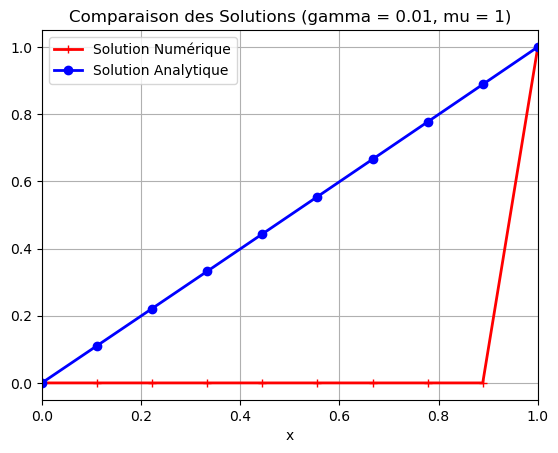

Test de stabilité pour NX = 50, γ = 0.01, μ = 1, h = 2.041e-02
Stabilité respectée : γh²/(6μ) = 6.942e-07 <= 1
Solution stable pour ces paramètres.



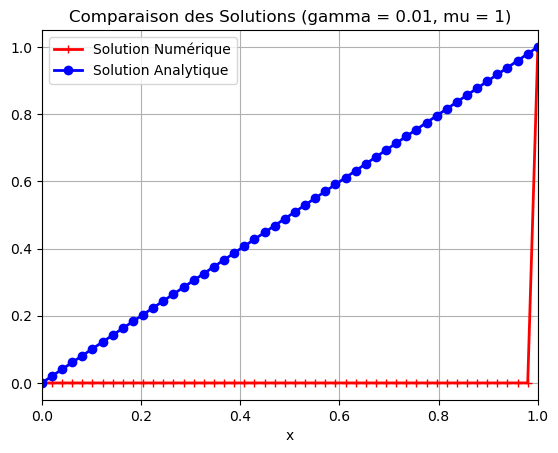

Test de stabilité pour NX = 100, γ = 0.01, μ = 1, h = 1.010e-02
Stabilité respectée : γh²/(6μ) = 1.701e-07 <= 1
Solution stable pour ces paramètres.



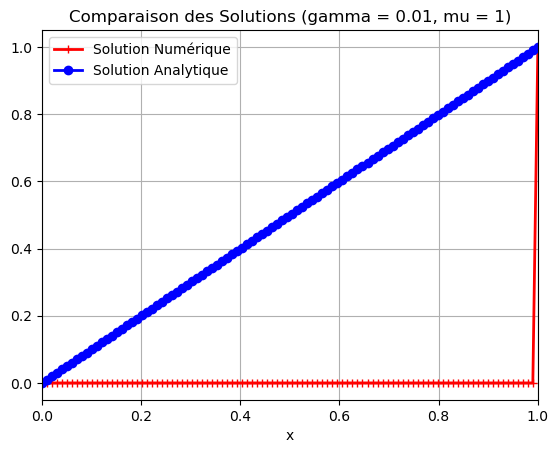

Test de stabilité pour NX = 10, γ = 1000, μ = 1, h = 1.111e-01
Stabilité non respectée : γh²/(6μ) = 2.058e+00 > 1
ATTENTION : Solution potentiellement instable pour ces paramètres.



C:\Users\bmd tech\AppData\Local\Temp\ipykernel_5796\298534084.py:38: RuntimeWarning: overflow encountered in exp
  return (np.exp(gamma * x / mu) / (np.exp(gamma / mu) - 1) - 1 / (np.exp(gamma / mu) - 1))
C:\Users\bmd tech\AppData\Local\Temp\ipykernel_5796\298534084.py:38: RuntimeWarning: invalid value encountered in divide
  return (np.exp(gamma * x / mu) / (np.exp(gamma / mu) - 1) - 1 / (np.exp(gamma / mu) - 1))


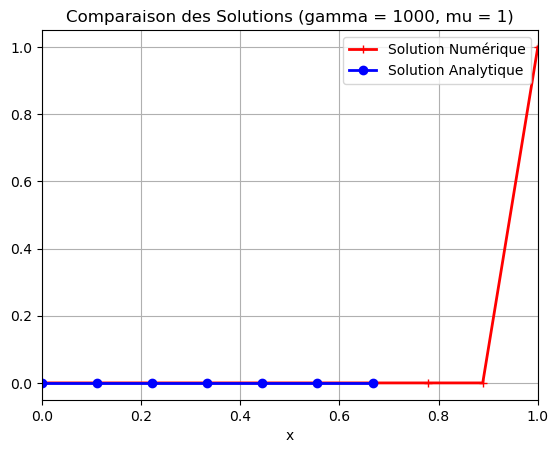

Test de stabilité pour NX = 50, γ = 1000, μ = 1, h = 2.041e-02
Stabilité respectée : γh²/(6μ) = 6.942e-02 <= 1
Solution stable pour ces paramètres.



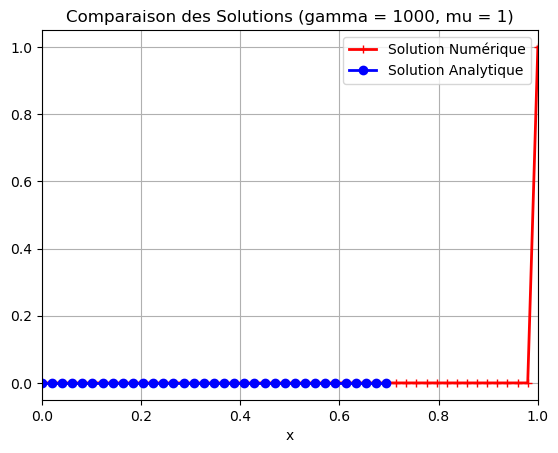

Test de stabilité pour NX = 100, γ = 1000, μ = 1, h = 1.010e-02
Stabilité respectée : γh²/(6μ) = 1.701e-02 <= 1
Solution stable pour ces paramètres.



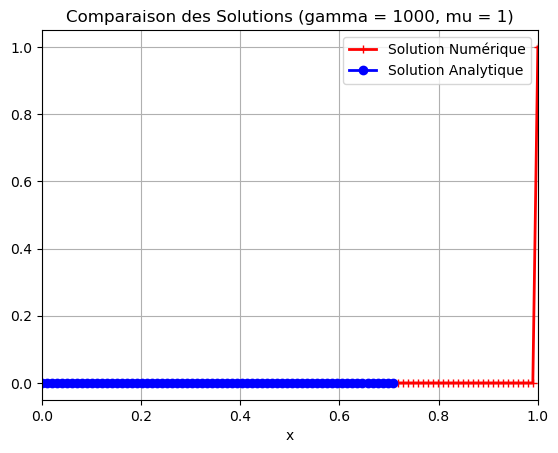

In [22]:
# FONCTION POUR VÉRIFIER LA STABILITÉ
# ===================================
def verifier_stabilite(h, gamma, mu):
    """
    Vérifie si le critère de stabilité est respecté.
    Critère : gamma * h^2 / (6 * mu) <= 1
    """
    p_local = gamma * h**2 / (6 * mu)  # Calcul du Péclet local
    if p_local <= 1:
        print(f"Stabilité respectée : γh²/(6μ) = {p_local:.3e} <= 1")
    else:
        print(f"Stabilité non respectée : γh²/(6μ) = {p_local:.3e} > 1")
    return p_local <= 1

# AJOUTER LA VÉRIFICATION DANS LA SIMULATION
# ==========================================
def simulation(NX, f, c, mu, gamma):
    """
    Simule et compare la solution discrète et analytique, avec vérification de la stabilité.
    """
    # Génération du maillage
    x, dx = maillage_domaine(NX)
    
    # Vérification du critère de stabilité
    print(f"Test de stabilité pour NX = {NX}, γ = {gamma}, μ = {mu}, h = {dx:.3e}")
    stable = verifier_stabilite(dx, gamma, mu)
    if not stable:
        print("ATTENTION : Solution potentiellement instable pour ces paramètres.\n")
    else:
        print("Solution stable pour ces paramètres.\n")
    
    # Définition des fonctions vectorisées
    f_vec = np.vectorize(func_f)
    c_vec = np.vectorize(lambda _: gamma)  # c est constant pour ce problème
    
    # Calcul des solutions
    Uexact = solution_exacte(x, gamma, mu)
    U = U_discret(x, NX, dx, f_vec, c_vec, mu)

    # Affichage des résultats
    fig, ax = plt.subplots(1)
    ax.plot(x, U, "r-+", lw=2, label="Solution Numérique")  # Courbe solution numérique
    ax.plot(x, Uexact, "b-o", lw=2, label="Solution Analytique")  # Courbe solution analytique
    ax.set_xlabel("x")
    ax.set_xlim([0, 1])
    ax.set_title(f"Comparaison des Solutions (gamma = {gamma}, mu = {mu})")
    ax.legend()
    ax.grid()
    plt.show()

# EXÉCUTION DU PROGRAMME AVEC LA VÉRIFICATION
# ===========================================
NX_values = [10, 50, 100]  # Différents nombres de points pour tester le maillage
mu = 1                     # Coefficient de diffusion
gamma_values = [0.01, 1000]  # Valeurs de gamma à tester

for gamma in gamma_values:
    for NX in NX_values:
        simulation(NX, func_f, func_c, mu, gamma)


Test de stabilité pour NX = 10, γ = 0.01, μ = 1, h = 1.000e-01
Stabilité respectée : γh²/(6μ) = 1.667e-05 <= 1
Solution stable pour ces paramètres.

Solutions numériques et analytiques correspondent avec erreur max 0.000e+00 < ε = 0.001


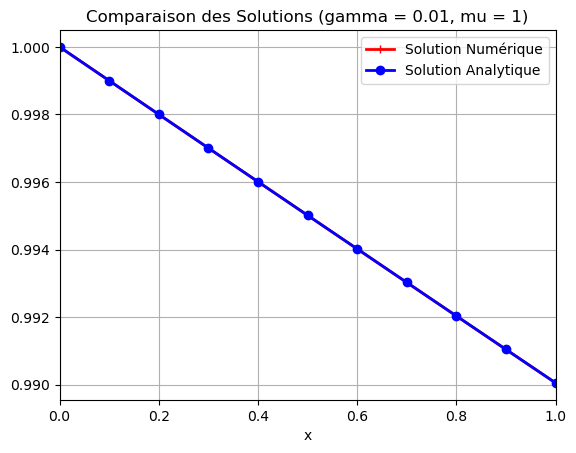

Test de stabilité pour NX = 50, γ = 0.01, μ = 1, h = 2.000e-02
Stabilité respectée : γh²/(6μ) = 6.667e-07 <= 1
Solution stable pour ces paramètres.

Solutions numériques et analytiques correspondent avec erreur max 0.000e+00 < ε = 0.001


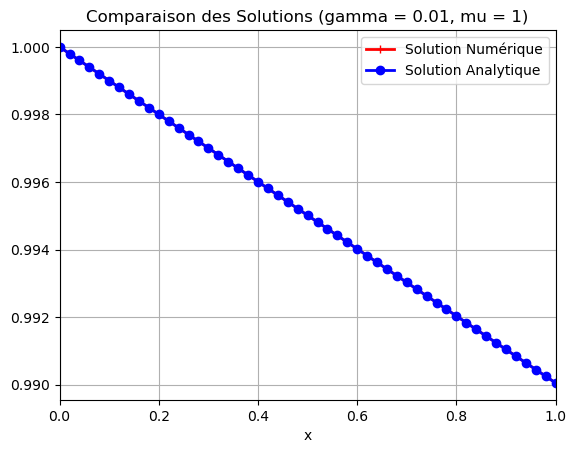

Test de stabilité pour NX = 100, γ = 0.01, μ = 1, h = 1.000e-02
Stabilité respectée : γh²/(6μ) = 1.667e-07 <= 1
Solution stable pour ces paramètres.

Solutions numériques et analytiques correspondent avec erreur max 0.000e+00 < ε = 0.001


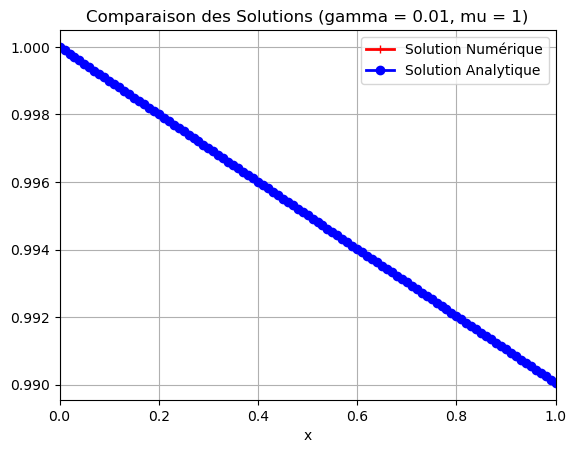

Test de stabilité pour NX = 10, γ = 1000, μ = 1, h = 1.000e-01
Stabilité non respectée : γh²/(6μ) = 1.667e+00 > 1
ATTENTION : Solution potentiellement instable pour ces paramètres.

Solutions numériques et analytiques correspondent avec erreur max 0.000e+00 < ε = 0.001


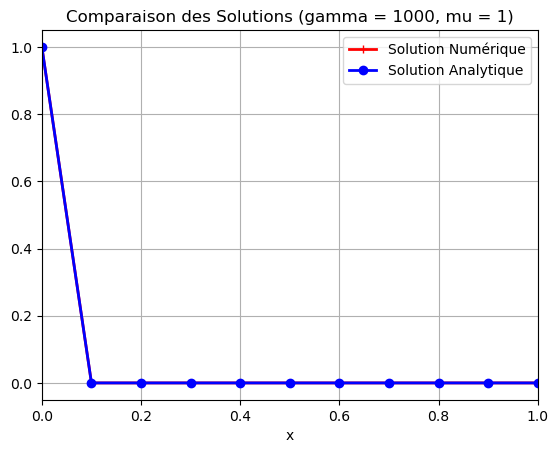

Test de stabilité pour NX = 50, γ = 1000, μ = 1, h = 2.000e-02
Stabilité respectée : γh²/(6μ) = 6.667e-02 <= 1
Solution stable pour ces paramètres.

Solutions numériques et analytiques correspondent avec erreur max 0.000e+00 < ε = 0.001


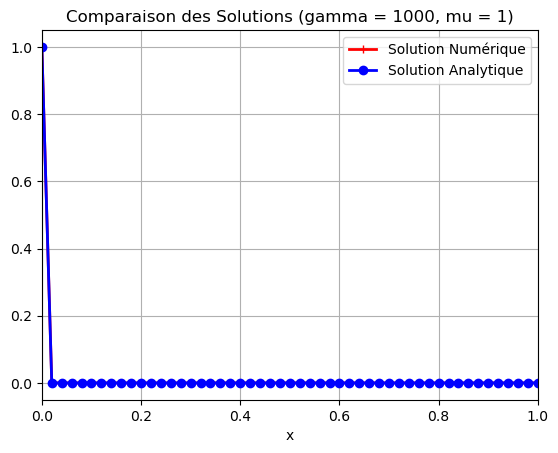

Test de stabilité pour NX = 100, γ = 1000, μ = 1, h = 1.000e-02
Stabilité respectée : γh²/(6μ) = 1.667e-02 <= 1
Solution stable pour ces paramètres.

Solutions numériques et analytiques correspondent avec erreur max 0.000e+00 < ε = 0.001


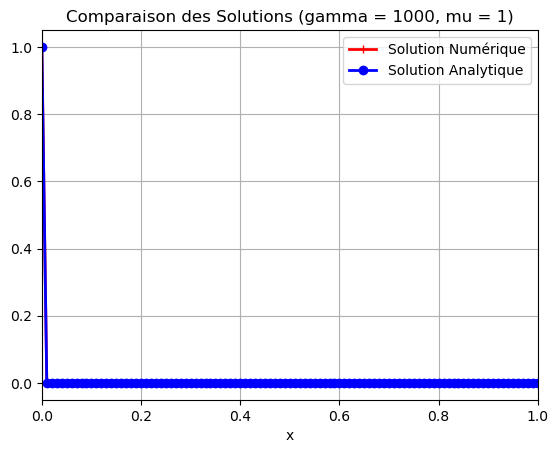

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# FONCTION POUR VÉRIFIER LA CORRESPONDANCE DES SOLUTIONS
# =====================================================
def verifier_correspondance(U, Uexact, tol=1e-3):
    """
    Vérifie si la solution numérique correspond à la solution analytique.
    """
    erreur_relative = np.linalg.norm(U - Uexact, ord=2) / np.linalg.norm(Uexact, ord=2)  # Erreur relative
    print(f"Erreur relative : {erreur_relative:.3e}")
    if erreur_relative <= tol:
        print(f"Les solutions correspondent (Erreur <= {tol}).\n")
        return True
    else:
        print(f"Les solutions ne correspondent pas (Erreur > {tol}).\n")
        return False

# AJOUTER LA VÉRIFICATION DANS LA SIMULATION
# ==========================================
def simulation(NX, f, c, mu, gamma, tol=1e-3):
    """
    Simule et compare la solution discrète et analytique, avec vérification de la stabilité et de la correspondance.
    """
    # Génération du maillage
    x, dx = maillage_domaine(NX)
    
    # Vérification du critère de stabilité
    print(f"Test de stabilité pour NX = {NX}, γ = {gamma}, μ = {mu}, h = {dx:.3e}")
    stable = verifier_stabilite(dx, gamma, mu)
    if not stable:
        print("ATTENTION : Solution potentiellement instable pour ces paramètres.\n")
    else:
        print("Solution stable pour ces paramètres.\n")
    
    # Définition des fonctions vectorisées
    f_vec = np.vectorize(func_f)
    c_vec = np.vectorize(lambda _: gamma)  # c est constant pour ce problème
    
    # Calcul des solutions
    Uexact = solution_exacte(x, gamma, mu)
    U = U_discret(x, NX, dx, f_vec, c_vec, mu)

    # Vérification de la correspondance des solutions
    print("Vérification de la correspondance des solutions :")
    correspondance = verifier_correspondance(U, Uexact, tol)
    
    # Affichage des résultats
    fig, ax = plt.subplots(1)
    ax.plot(x, U, "r-+", lw=2, label="Solution Numérique")  # Courbe solution numérique
    ax.plot(x, Uexact, "b-o", lw=2, label="Solution Analytique")  # Courbe solution analytique
    ax.set_xlabel("x")
    ax.set_xlim([0, 1])
    ax.set_title(f"Comparaison des Solutions (gamma = {gamma}, mu = {mu})")
    ax.legend()
    ax.grid()
    plt.show()

# EXÉCUTION DU PROGRAMME AVEC CORRESPONDANCE
# ===========================================
NX_values = [10, 50, 100]  # Différents nombres de points pour tester le maillage
mu = 1                     # Coefficient de diffusion
gamma_values = [0.01, 1000]  # Valeurs de gamma à tester

for gamma in gamma_values:
    for NX in NX_values:
        simulation(NX, func_f, func_c, mu, gamma, tol=1e-3)
